### Rolling Light

## Import libraries

In [25]:
#!pip install imblearn

In [26]:
import pandas as pd
import numpy as np

import glob
import os

import requests

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import zipfile

import xarray as xr

import folium
from folium.plugins import MarkerCluster

import pandas as pd
from geopy.geocoders import Nominatim

import geopandas as gpd
import cartopy.crs as ccrs

import imageio

from sklearn.neighbors import KDTree
from sklearn.neighbors import BallTree

from sklearn.preprocessing import RobustScaler

## Set parameters

In [27]:
decree_filename_base = 'arrete_'
decrees_folder_name = './../../data/raw/decrees'
communes_folder_name = './../../data/raw/opendatasoft'
weather_folder_name = './../../data/raw/weather/era5'
weather_ncfiles_folder_name = './../../data/raw/weather/era5/ncfiles2'
processed_data_folder_name = './../../data/processed'
output_data_folder_name = './../../data/processed/output'
decrees_filename = 'decrees.parquet'
decrees_locations_filename = 'decrees_locations.parquet'
communes_csv_filename = 'correspondance-code-insee-code-postal-202410.csv'
weather_filename = 'weather2.parquet'
weather_shema_filename = 'weather_shema2.csv'
weather_yearly_filename = 'weather2_yearly.parquet'
weather_yearly_shema_filename = 'weather_shema2_yearly.csv'
drought_filename = 'drought.parquet'
drought_shema_filename = 'drought_shema.csv'
drought_yearly_filename = 'drought_yearly.parquet'
drought_yearly_shema_filename = 'drought_yearly_shema.csv'
drought_commune_clean_filename = 'drought_commune_clean.parquet'
drought_commune_clean_shema_filename = 'drought_commune_clean_shema.csv'
drought_weather_filename = 'drought_weather.parquet'
drought_weather_shema_filename = 'drought_weather_shema.csv'
#weather_zip_file = "193fcd51a8958175843ecbbcaba057c8.zip"

## Load data

| Column    | Description                                      |
|-----------|--------------------------------------------------|
| date      | The date of the observation.                     |
| latitude  | The latitude coordinate of the observation point.|
| longitude | The longitude coordinate of the observation point.|
| number    | A unique identifier for the observation.         |
| expver    | Experiment version number.                       |
| u10       | 10-meter U-component of wind (eastward wind).    |
| v10       | 10-meter V-component of wind (northward wind).   |
| t2m       | 2-meter temperature (air temperature at 2 meters above the surface).|
| sp        | Surface pressure.                                |
| tp        | Total precipitation.                             |
| e         | Evaporation.                                     |
| sro       | Surface runoff.                                  |
| tcrw      | Total column water vapor.                        |
| stl1      | Soil temperature level 1.                        |
| stl2      | Soil temperature level 2.                        |
| slt       | Soil type.                                       |
| swvl1     | Volumetric soil water layer 1.                   |
| swvl2     | Volumetric soil water layer 2.                   |
| cvh       | High vegetation cover.                           |
| cvl       | Low vegetation cover.                            |
| tvh       | High vegetation type.                            |
| tvl       | Low vegetation type.                             |


## Import Data

In [28]:
# read the dataframe from parquet
import pandas as pd

df = pd.read_parquet(os.path.join(processed_data_folder_name, drought_weather_filename))




In [29]:
os.path.join(processed_data_folder_name, drought_weather_shema_filename)

'./../../data/processed/drought_weather_shema.csv'

In [30]:
# Load the schema (data types) from the file
schema = pd.read_csv(os.path.join(processed_data_folder_name, drought_weather_shema_filename), index_col=0).squeeze("columns")

In [31]:
# Apply the schema to the loaded dataframe
df = df.astype(schema.to_dict())

In [32]:
df_ori = df.copy()
# Remove rows where applied_1 is equal to 0
#df = df[df['applied_1'] != 0]



print(df)


      insee_1        nom_commune_1  latitude_1  longitude_1  year_1  \
0       10002           AILLEVILLE   48.255000     4.694493    2000   
1       10003          AIX-EN-OTHE   48.197575     3.736328    2000   
2       10004        ALLIBAUDIERES   48.586400     4.122928    2000   
3       10005               AMANCE   48.291854     4.487049    2000   
4       10006       ARCIS-SUR-AUBE   48.527827     4.141971    2000   
...       ...                  ...         ...          ...     ...   
36009   95675             VILLERON   49.060843     2.534511    2023   
36010   95676   VILLERS-EN-ARTHIES   49.085900     1.730396    2023   
36011   95678        VILLIERS-ADAM   49.070289     2.239509    2023   
36012   95682      VILLIERS-LE-SEC   49.074309     2.386890    2023   
36013   95690  WY-DIT-JOLI-VILLAGE   49.095820     1.825029    2023   

       year_count_1  year_duration_1  applied_1  decision_1 Code Postal_1  \
0               NaN              NaN          0           0         10

In [33]:
df.head()

,insee_1,nom_commune_1,latitude_1,longitude_1,year_1,year_count_1,year_duration_1,applied_1,decision_1,Code Postal_1,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
0,10002,AILLEVILLE,48.255000,4.694493,2000,NaN,NaN,0,0,10200,...,11.360728,36.0,3.0,4.290780,0.357565,4.225537,0.352128,0.842121,0.082903,4.147094
1,10003,AIX-EN-OTHE,48.197575,3.736328,2000,NaN,NaN,0,0,10160,...,11.673390,24.0,2.0,4.221337,0.351778,4.156231,0.346353,0.842121,0.065450,5.916774
2,10004,ALLIBAUDIERES,48.586400,4.122928,2000,NaN,NaN,0,0,10700,...,11.781789,24.0,2.0,4.192894,0.349408,4.119763,0.343314,0.846485,0.069813,13.198245
3,10005,AMANCE,48.291854,4.487049,2000,NaN,NaN,0,0,10140,...,11.527883,24.0,2.0,4.238762,0.353230,4.164776,0.347065,0.842121,0.078540,4.751647
4,10006,ARCIS-SUR-AUBE,48.527827,4.141971,2000,NaN,NaN,0,0,10700,...,11.784230,24.0,2.0,4.209328,0.350777,4.135861,0.344655,0.846485,0.074176,8.537810


In [34]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'year_count_1', 'year_duration_1', 'applied_1', 'decision_1',
       'Code Postal_1', 'Département_1', 'Région_1', 'Code Département_1',
       'Code Région_1', 'latitude_rad_1', 'longitude_rad_1', 'latitude_2',
       'longitude_2', 'year_2', 't2m_z_sum_2', 't2m_z_mean_2', 'tp_z_sum_2',
       'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2', 'pev_z_sum_2', 'pev_z_mean_2',
       'stl1_z_sum_2', 'stl1_z_mean_2', 'stl2_z_sum_2', 'stl2_z_mean_2',
       'slt_z_sum_2', 'slt_z_mean_2', 'swvl1_z_sum_2', 'swvl1_z_mean_2',
       'swvl2_z_sum_2', 'swvl2_z_mean_2', 't2m_sum_2', 't2m_mean_2',
       'tp_sum_2', 'tp_mean_2', 'e_sum_2', 'e_mean_2', 'pev_sum_2',
       'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2', 'stl2_sum_2', 'stl2_mean_2',
       'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2', 'swvl1_mean_2', 'swvl2_sum_2',
       'swvl2_mean_2', 'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object')

In [35]:
df.dtypes

insee_1                object
nom_commune_1          object
latitude_1            float64
longitude_1           float64
year_1                  int64
year_count_1          float64
year_duration_1       float64
applied_1               int64
decision_1              int64
Code Postal_1          object
Département_1          object
Région_1               object
Code Département_1     object
Code Région_1           int64
latitude_rad_1        float64
longitude_rad_1       float64
latitude_2            float64
longitude_2           float64
year_2                  int32
t2m_z_sum_2           float64
t2m_z_mean_2          float64
tp_z_sum_2            float64
tp_z_mean_2           float64
e_z_sum_2             float64
e_z_mean_2            float64
pev_z_sum_2           float64
pev_z_mean_2          float64
stl1_z_sum_2          float64
stl1_z_mean_2         float64
stl2_z_sum_2          float64
stl2_z_mean_2         float64
slt_z_sum_2           float64
slt_z_mean_2          float64
swvl1_z_su

In [36]:
df.select_dtypes(include=['object']).describe()

,insee_1,nom_commune_1,Code Postal_1,Département_1,Région_1,Code Département_1
count,868454,868454,868454,868454,868454,868454
unique,35958,33400,5862,96,22,96
top,47032,SAINTE-COLOMBE,51300,['PAS-DE-CALAIS'],['MIDI-PYRENEES'],62
freq,37,339,1104,21034,71376,21034


In [37]:
df.select_dtypes(include=['int32', 'int64']).describe()

,year_1,applied_1,decision_1,Code Région_1,year_2
count,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000
mean,2011.496121,0.445718,0.038123,49.226947,2011.496121
std,6.910162,0.497045,0.191493,25.119029,6.910162
min,2000.000000,0.000000,0.000000,11.000000,2000.000000
25%,2006.000000,0.000000,0.000000,25.000000,2006.000000
50%,2011.000000,0.000000,0.000000,43.000000,2011.000000
75%,2017.000000,1.000000,0.000000,73.000000,2017.000000
max,2023.000000,1.000000,1.000000,94.000000,2023.000000


In [38]:
df.select_dtypes(include=['float32', 'float64']).describe()

,latitude_1,longitude_1,year_count_1,year_duration_1,latitude_rad_1,longitude_rad_1,latitude_2,longitude_2,t2m_z_sum_2,t2m_z_mean_2,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
count,868454.000000,868454.000000,387086.000000,387086.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,...,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000,868454.000000
mean,47.018240,2.685467,1.019593,1.024571,0.820623,0.046870,47.018081,2.685476,4.617781,0.384815,...,11.651255,28.554300,2.379525,3.882993,0.323583,3.799258,0.316605,0.820620,0.046870,9.042732
std,2.164815,2.596413,0.267611,0.333465,0.037783,0.045316,2.166321,2.596766,4.183193,0.348599,...,1.704982,7.760094,0.646675,0.572538,0.047712,0.588889,0.049074,0.037809,0.045322,3.553215
min,42.285250,-5.085345,1.000000,1.000000,0.738017,-0.088756,42.500000,-5.000000,-9.260896,-0.771741,...,1.713064,0.000000,0.000000,-0.000040,-0.000003,-0.000050,-0.000004,0.741765,-0.087266,0.060873
25%,45.239864,0.659644,1.000000,1.000000,0.789585,0.011513,45.250000,0.750000,1.546452,0.128871,...,10.737213,24.000000,2.000000,3.713022,0.309419,3.587671,0.298973,0.789761,0.013090,6.460281
50%,47.426567,2.607542,1.000000,1.000000,0.827750,0.045510,47.500000,2.500000,5.069161,0.422430,...,11.595448,24.000000,2.000000,3.944875,0.328740,3.855600,0.321300,0.829031,0.043633,9.150935
75%,48.843291,4.821226,1.000000,1.000000,0.852476,0.084146,48.750000,4.750000,7.893278,0.657773,...,12.635692,36.000000,3.000000,4.165593,0.347133,4.115305,0.342942,0.850848,0.082903,11.835353
max,51.063772,8.825756,13.000000,13.000000,0.891231,0.154038,51.000000,8.500000,17.793317,1.482776,...,19.520823,48.000000,4.000000,5.718729,0.476561,5.756094,0.479674,0.890118,0.148353,35.531838


In [39]:
def plot_distance_boxplot(df):
    fig = px.box(df, y='distance_km', title='Boxplot of Distance (km)', labels={'distance_km': 'Distance (km)'})
    fig.show()

# Example usage for the plot:
# plot_distance_boxplot(df)

In [40]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'year_count_1', 'year_duration_1', 'applied_1', 'decision_1',
       'Code Postal_1', 'Département_1', 'Région_1', 'Code Département_1',
       'Code Région_1', 'latitude_rad_1', 'longitude_rad_1', 'latitude_2',
       'longitude_2', 'year_2', 't2m_z_sum_2', 't2m_z_mean_2', 'tp_z_sum_2',
       'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2', 'pev_z_sum_2', 'pev_z_mean_2',
       'stl1_z_sum_2', 'stl1_z_mean_2', 'stl2_z_sum_2', 'stl2_z_mean_2',
       'slt_z_sum_2', 'slt_z_mean_2', 'swvl1_z_sum_2', 'swvl1_z_mean_2',
       'swvl2_z_sum_2', 'swvl2_z_mean_2', 't2m_sum_2', 't2m_mean_2',
       'tp_sum_2', 'tp_mean_2', 'e_sum_2', 'e_mean_2', 'pev_sum_2',
       'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2', 'stl2_sum_2', 'stl2_mean_2',
       'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2', 'swvl1_mean_2', 'swvl2_sum_2',
       'swvl2_mean_2', 'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object')

In [41]:
z_columns = [col for col in df.columns if '_z_' in col]
z_columns

['t2m_z_sum_2',
 't2m_z_mean_2',
 'tp_z_sum_2',
 'tp_z_mean_2',
 'e_z_sum_2',
 'e_z_mean_2',
 'pev_z_sum_2',
 'pev_z_mean_2',
 'stl1_z_sum_2',
 'stl1_z_mean_2',
 'stl2_z_sum_2',
 'stl2_z_mean_2',
 'slt_z_sum_2',
 'slt_z_mean_2',
 'swvl1_z_sum_2',
 'swvl1_z_mean_2',
 'swvl2_z_sum_2',
 'swvl2_z_mean_2']

In [42]:
df['decision_1'].describe()

count    868454.000000
mean          0.038123
std           0.191493
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: decision_1, dtype: float64

In [43]:
df['decision_1'].value_counts()

decision_1
0    835346
1     33108
Name: count, dtype: int64

In [44]:
# Select columns that contain '_sum' and '_mean' but not '_z'
selected_columns = [col for col in df.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]

# Create a new DataFrame with the selected columns
df_selected = df[selected_columns]

print(df_selected.columns)

Index(['t2m_sum_2', 't2m_mean_2', 'tp_sum_2', 'tp_mean_2', 'e_sum_2',
       'e_mean_2', 'pev_sum_2', 'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2',
       'stl2_sum_2', 'stl2_mean_2', 'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2',
       'swvl1_mean_2', 'swvl2_sum_2', 'swvl2_mean_2'],
      dtype='object')


In [45]:
df['year_1'].describe()

count    868454.000000
mean       2011.496121
std           6.910162
min        2000.000000
25%        2006.000000
50%        2011.000000
75%        2017.000000
max        2023.000000
Name: year_1, dtype: float64

In [46]:
df = df[df['year_1'] <= 2020]

In [47]:
df['year_count_1'].describe()

count    338973.000000
mean          1.020291
std           0.271794
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          13.000000
Name: year_count_1, dtype: float64

In [48]:
df = df[df['year_count_1'] == 1]

## Models

### Boosting

#### xgboost

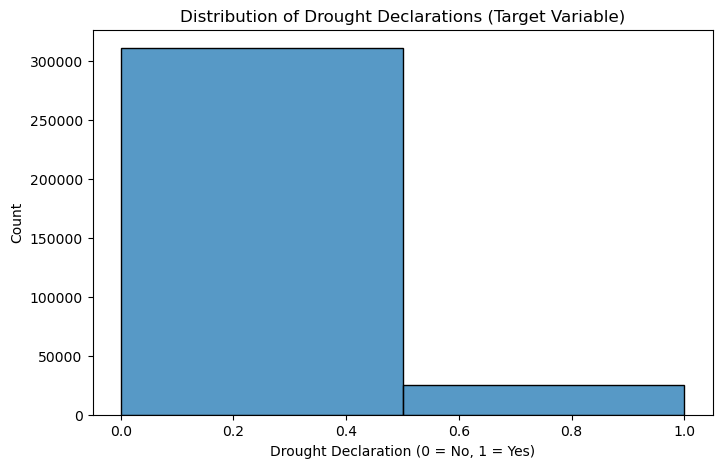

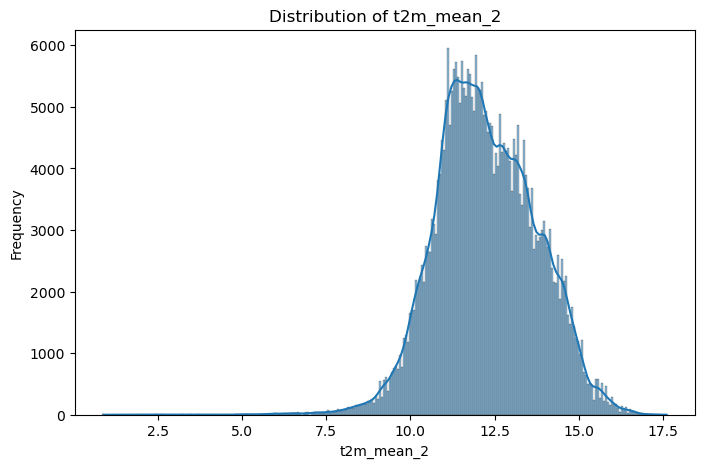

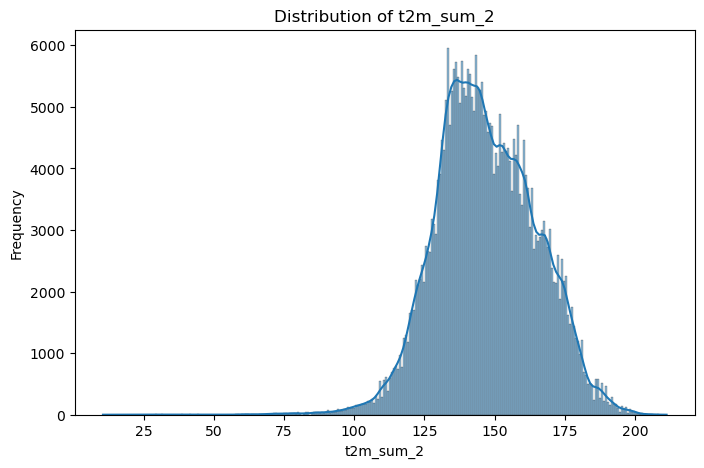

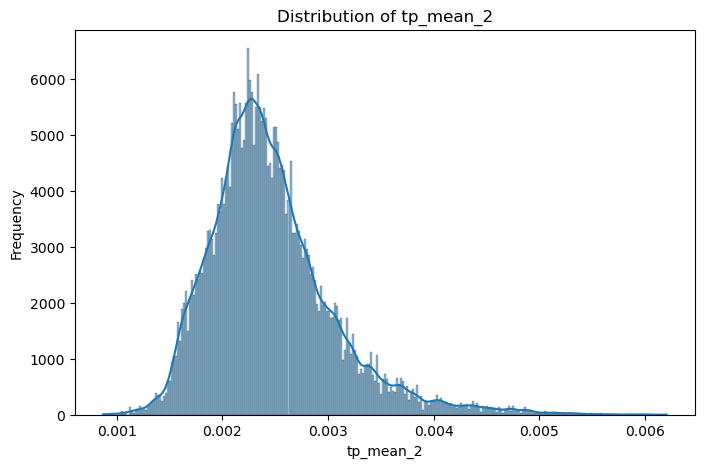

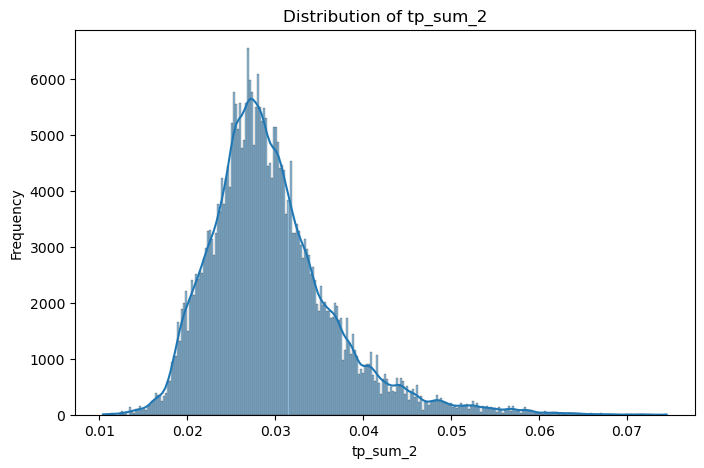

[I 2024-11-03 00:40:15,205] A new study created in memory with name: no-name-88f62fcb-ae04-402e-a8c7-21c6c47fa8d8


Training set shape: (256578, 150)
Testing set shape: (79339, 150)
[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003024 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[I 2024-11-03 00:40:16,091] Trial 0 finished with value: 0.29784589892294944 and parameters: {'n_estimators': 194, 'max_depth': 8, 'learning_rate': 0.06292951314832636, 'subsample': 0.9474423120086283, 'colsample_bytree': 0.5901168304362121}. Best is trial 0 with value: 0.29784589892294944.


[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[I 2024-11-03 00:40:17,122] Trial 1 finished with value: 0.32363493518397274 and parameters: {'n_estimators': 166, 'max_depth': 9, 'learning_rate': 0.006160543719885649, 'subsample': 0.9544118020053136, 'colsample_bytree': 0.6951461902049251}. Best is trial 1 with value: 0.32363493518397274.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001610 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is

[I 2024-11-03 00:41:07,696] Trial 48 finished with value: 0.3279781537042948 and parameters: {'n_estimators': 102, 'max_depth': 3, 'learning_rate': 0.007077767031307863, 'subsample': 0.8302622538872437, 'colsample_bytree': 0.7391530239135566}. Best is trial 42 with value: 0.33046280348908275.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 12153, number of negative: 244425
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002554 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4090
[LightGBM] [Info] Number of data points in the train set: 256578, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[I 2024-11-03 00:41:08,152] Trial 49 finished with value: 0.32609512898086324 and parameters: {'n_estimators': 105, 'max_depth': 3, 'learning_rate': 0.007147244094724656, 'subsample': 0.8209592011661888, 'colsample_bytree': 0.5892712425733265}. Best is trial 42 with value: 0.33046280348908275.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

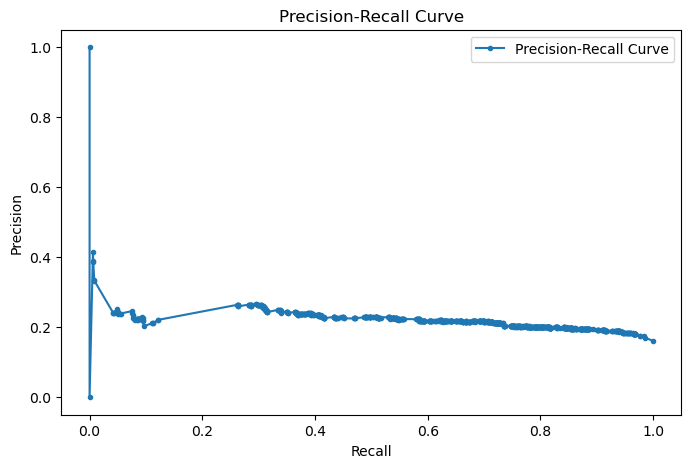

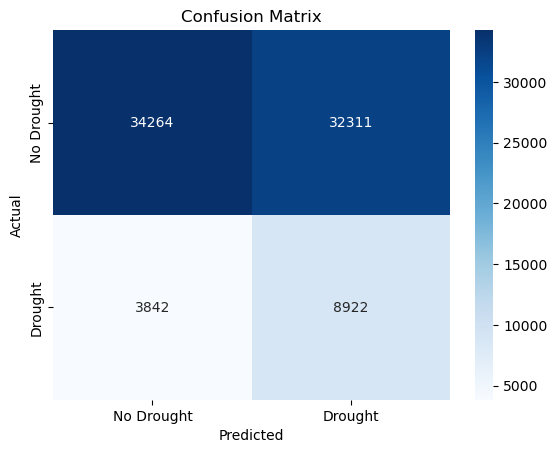

Summary Performance for the Optimized LightGBM Model:
Recall: 0.6990
F1 Score: 0.3305
ROC AUC Score: 0.6384
Classification Report:
              precision    recall  f1-score   support

  No Drought       0.90      0.51      0.65     66575
     Drought       0.22      0.70      0.33     12764

    accuracy                           0.54     79339
   macro avg       0.56      0.61      0.49     79339
weighted avg       0.79      0.54      0.60     79339

Best Hyperparameters found by Optuna:
{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.02461983131308101, 'subsample': 0.8741062369642062, 'colsample_bytree': 0.6550715324967189}


In [50]:
# Predicting Drought Emergency Declarations for French Communes

# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from lightgbm import LGBMClassifier
import optuna
import datetime
import warnings
warnings.filterwarnings("ignore")

# Step 1: Load the Dataset
# Assuming that the dataset is in CSV format
# Uncomment and load your dataset here
# df = pd.read_csv('french_communes_weather.csv')

# Step 2: Data Preprocessing
# Make a copy of the original dataframe to work on
# This ensures that the original data remains intact
## Create a copy of the dataset to work on
# Filter data to only use years between 2000 and 2020
df_copy = df[(df['year_1'] >= 2000) & (df['year_1'] <= 2020)].copy()

# Rename 'Code Département_1' to 'Code_Departement_1' to avoid whitespace issues
if 'Code Département_1' in df_copy.columns:
    df_copy.rename(columns={'Code Département_1': 'Code_Departement_1'}, inplace=True)

# Handle Categorical Features using OneHotEncoder
## Encode "Code_Departement_1" if it exists in the dataset
if 'Code_Departement_1' in df_copy.columns:
    onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_departments = onehot_encoder.fit_transform(df_copy[['Code_Departement_1']])
    department_encoded_df = pd.DataFrame(encoded_departments, columns=onehot_encoder.get_feature_names_out(['Code_Departement_1']))

    # Reset indexes to ensure proper concatenation
    df_copy = df_copy.reset_index(drop=True)
    department_encoded_df = department_encoded_df.reset_index(drop=True)

    # Add the encoded department columns to the original dataframe copy and drop the original column
    df_copy = pd.concat([df_copy.drop(columns=['Code_Departement_1']), department_encoded_df], axis=1)
else:
    print("The column 'Code_Departement_1' was not found in the dataset. Please verify the column name.")

# Step 3: Exploratory Data Analysis (EDA)
# Understand the distribution of the target variable
def plot_target_variable_distribution():
    plt.figure(figsize=(8, 5))
    sns.histplot(df_copy['decision_1'], kde=False, bins=2)
    plt.title('Distribution of Drought Declarations (Target Variable)')
    plt.xlabel('Drought Declaration (0 = No, 1 = Yes)')
    plt.ylabel('Count')
    plt.show()

# Plot the target variable distribution
plot_target_variable_distribution()

# Exploratory Visualizations - Plot the distribution of temperature and precipitation features
# Selected columns for temperature and precipitation
weather_columns = ['t2m_mean_2', 't2m_sum_2', 'tp_mean_2', 'tp_sum_2']

def plot_feature_distributions(columns):
    for col in columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df_copy[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

# Plot the feature distributions
plot_feature_distributions(weather_columns)

# Step 4: Data Splitting - Temporal Awareness
# Sort data by year to respect the time order
df_copy = df_copy.sort_values(by='year_1')

# Split the dataset into training and testing sets based on temporal information
train = df_copy[df_copy['year_1'] < df_copy['year_1'].quantile(0.8)]
test = df_copy[df_copy['year_1'] >= df_copy['year_1'].quantile(0.8)]

# Print training and testing data shapes
print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

# Step 5: Defining Features and Target Variables
# Extract features and target variable
target = 'decision_1'
weather_features = [col for col in df_copy.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]

# Include encoded department columns if applicable
all_features = list(department_encoded_df.columns) + weather_features if 'Code_Departement_1' in df.columns else weather_features

# Also include 'applied_1' as a categorical feature without OneHot Encoding if it exists
if 'applied_1' in df_copy.columns:
    all_features.append('applied_1')

# Split data into features and target variables
X_train = train[all_features]
y_train = train[target]
X_test = test[all_features]
y_test = test[target]

# Step 6: Building LightGBM Model Using Optuna for Hyperparameter Tuning
# Create the base LightGBM model
model = LGBMClassifier(random_state=42, class_weight='balanced')

# Define an objective function for Optuna to optimize
# This will define the hyperparameter search space
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0)
    }
    model.set_params(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    y_pred_binary = (y_pred > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred_binary, pos_label=1)
    return f1

# Run Optuna's optimization to find the best parameters for LightGBM
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Retrieve the best parameters and update the model
best_params = study.best_params
model.set_params(**best_params)
model.fit(X_train, y_train)

# Step 7: Make Predictions with the Best Model
# Make predictions on the test set
y_pred = model.predict_proba(X_test)[:, 1]
y_pred_binary = (y_pred > 0.5).astype(int)

# Step 8: Model Evaluation Metrics
# Calculate evaluation metrics for the model
recall = recall_score(y_test, y_pred_binary, pos_label=1)
f1 = f1_score(y_test, y_pred_binary, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred, average='weighted')

# Plot Precision-Recall Curve to evaluate model performance
precision, recall_curve, thresholds = precision_recall_curve(y_test, y_pred)
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision, marker='.', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Plot Confusion Matrix to visualize the classification performance
conf_matrix = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 9: Display Model Performance Summary
print(f"Summary Performance for the Optimized LightGBM Model:")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Drought', 'Drought'], zero_division=1))

# Print the best hyperparameters found by Optuna
print("Best Hyperparameters found by Optuna:")
print(best_params)

# End of Notebook
